In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Configuration de l'affichage des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [11]:
DATA_DIR = r"H:\Downloads\Move to Mars\raw_data"

In [ ]:
# 1. CHARGEMENT ET PRÉPARATIVE DES DONNÉES
df_colon = pd.read_csv(os.path.join(DATA_DIR, "COLON.csv"))
df_constantes = pd.read_csv(os.path.join(DATA_DIR, "CONSTANTE_VITALE.csv"))
df_metier = pd.read_csv(os.path.join(DATA_DIR, "CATEGORIE_METIER.csv"))
df_module = pd.read_csv(os.path.join(DATA_DIR, "MODULE.csv"))
df_temps = pd.read_csv(os.path.join(DATA_DIR, "DIM_TEMPS_MARS.csv"))
df_scenario = pd.read_csv(os.path.join(DATA_DIR, "SCENARIO.csv"))


In [ ]:
# Conversion des scores en numériques pour les statistiques
df_constantes['score_stress_num'] = pd.to_numeric(df_constantes['score_stress'], errors='coerce')
df_constantes['score_fatigue_num'] = pd.to_numeric(df_constantes['score_fatigue'], errors='coerce')

print(" Tables chargées et types ajustés avec succès.")


 Tables chargées et types ajustés avec succès.


### SECTION 1 : STATISTIQUES DESCRIPTIVES

In [ ]:
print("STATISTIQUES DESCRIPTIVES (CONSTANTES VITALES)")

vitals_cols = [
    'frequence_cardiaque_bpm', 
    'saturation_o2_pct', 
    'temperature_corporelle_c', 
    'score_stress_num', 
    'score_fatigue_num'
]

display(df_constantes[vitals_cols].describe().round(2))


STATISTIQUES DESCRIPTIVES (CONSTANTES VITALES)


,frequence_cardiaque_bpm,saturation_o2_pct,temperature_corporelle_c,score_stress_num,score_fatigue_num
count,216031.00,216031.00,216031.00,214139.00,214253.00
mean,81.96,96.82,36.94,43.01,38.91
std,15.08,2.36,0.61,14.62,12.39
min,65.00,89.50,36.20,0.00,0.00
25%,71.00,96.40,36.50,33.00,30.60
50%,78.00,97.40,36.80,42.90,38.90
75%,85.00,98.50,37.10,52.90,47.10
max,125.00,99.50,38.70,110.00,115.00


### SECTION 2 : RÈGLE MÉTIER & TAUX DE SANTÉ GLOBALE

In [20]:

print(" CALCUL DU KPI : TAUX DE SANTÉ GLOBALE")

# Seuil médical admis : SpO2 >= 95, BPM [60-100], Temp <= 37.5
df_constantes['est_sante_normale'] = (
    (df_constantes['saturation_o2_pct'] >= 95) & 
    (df_constantes['frequence_cardiaque_bpm'].between(60, 100)) & 
    (df_constantes['temperature_corporelle_c'] <= 37.5)
).astype(int)

total_mesures = len(df_constantes)
mesures_normales = df_constantes['est_sante_normale'].sum()
kpi_sante = (mesures_normales / total_mesures) * 100

print(f"• Total relevés médicaux : {total_mesures:,}")
print(f"• Relevés sains (normaux) : {mesures_normales:,}")
print(f"TAUX DE SANTÉ GLOBALE (RÉFÉRENCE EDA) : {kpi_sante:.2f}%")



 CALCUL DU KPI : TAUX DE SANTÉ GLOBALE
• Total relevés médicaux : 216,031
• Relevés sains (normaux) : 181,036
TAUX DE SANTÉ GLOBALE (RÉFÉRENCE EDA) : 83.80%


### SECTION 3 : VISUALISATIONS EXPLORATOIRES

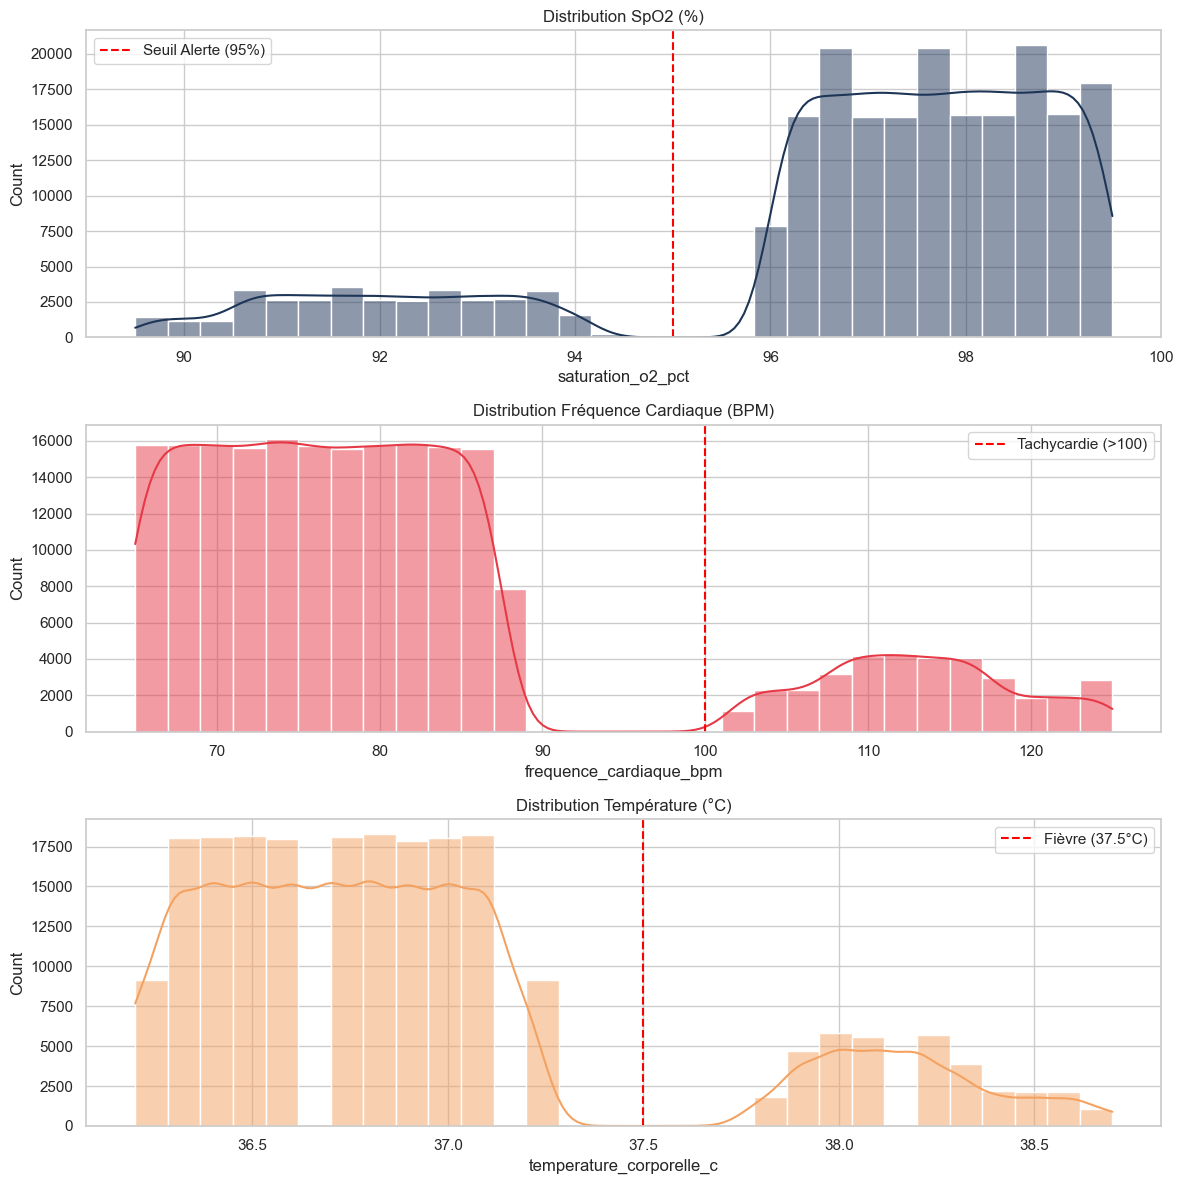

In [25]:
# 1. Distributions des Constantes Vitales (Empilées verticalement)
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Graphique 1 : SpO2
sns.histplot(df_constantes['saturation_o2_pct'], bins=30, kde=True, ax=axes[0], color='#1d3557')
axes[0].axvline(95, color='red', linestyle='--', label='Seuil Alerte (95%)')
axes[0].set_title('Distribution SpO2 (%)')
axes[0].legend()

# Graphique 2 : Fréquence Cardiaque (BPM)
sns.histplot(df_constantes['frequence_cardiaque_bpm'], bins=30, kde=True, ax=axes[1], color='#e63946')
axes[1].axvline(100, color='red', linestyle='--', label='Tachycardie (>100)')
axes[1].set_title('Distribution Fréquence Cardiaque (BPM)')
axes[1].legend()

# Graphique 3 : Température (°C)
sns.histplot(df_constantes['temperature_corporelle_c'], bins=30, kde=True, ax=axes[2], color='#f4a261')
axes[2].axvline(37.5, color='red', linestyle='--', label='Fièvre (37.5°C)')
axes[2].set_title('Distribution Température (°C)')
axes[2].legend()

plt.tight_layout()
plt.show()

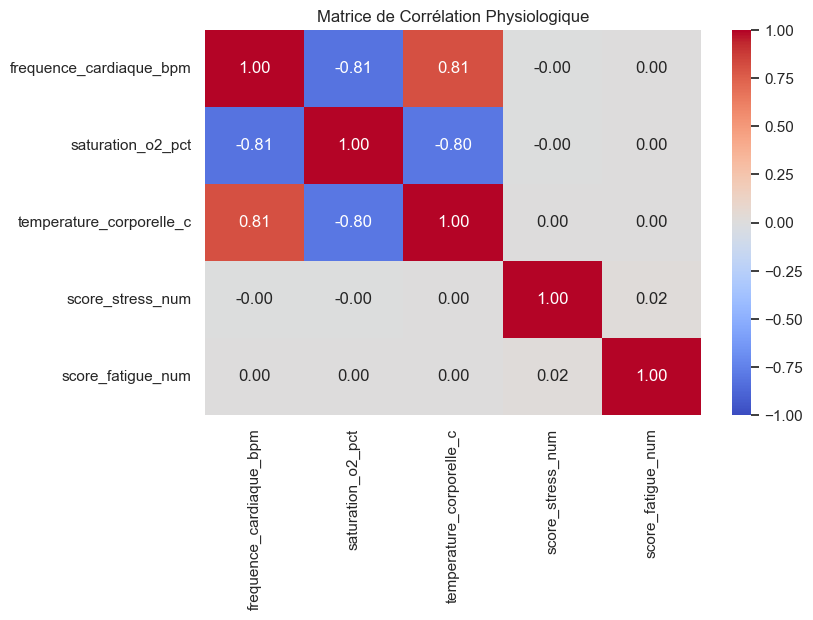

In [23]:

# Corrélation entre variables physiologiques
plt.figure(figsize=(8, 5))
sns.heatmap(df_constantes[vitals_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matrice de Corrélation Physiologique')
plt.show()

## Synthèse Exploratoire des Constantes Vitales

1. **Cohérence Physiologique Forte :** 
   Les données montrent une forte interdépendance entre SpO2, BPM et Température (|r| > 0.80). Un problème respiratoire (chute de SpO2) s'accompagne systématiquement d'une hausse du rythme cardiaque et de la température.

2. **Présence de Profils Multi-modaux (Clusters) :** 
   Chaque constante présente deux populations distinctes : un état de fonctionnement nominal (sain) et un état critique (alerte/maladie).

3. **Validation des Règles Métier pour Talend/Power BI :** 
   Les seuils d'alerte choisis (SpO2 < 95%, BPM > 100, Temp > 37.5°C) sont parfaitement adaptés pour isoler la population en détresse médicale.

### SECTION 4 : CROISEMENT AVEC LES DIMENSIONS



--- Analyse de la Santé par Métier ---


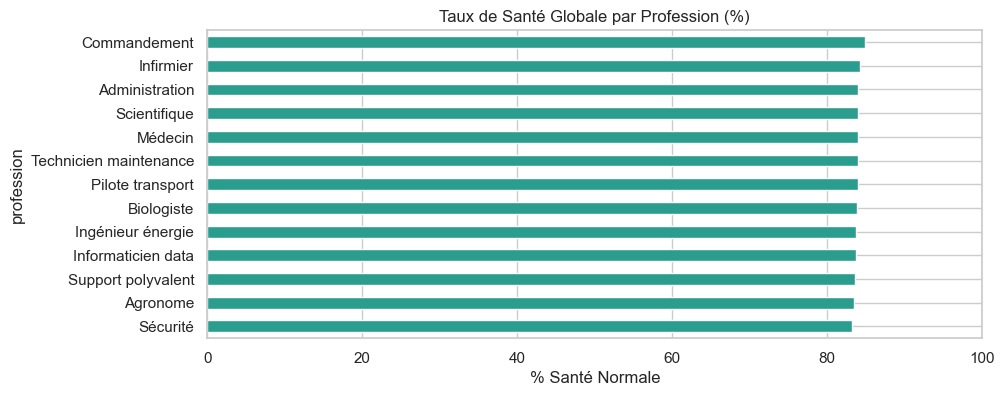

In [26]:
# Analyse du Taux de Santé par Profession / Métier
print("\n--- Analyse de la Santé par Métier ---")
df_merged_colon = df_constantes.merge(df_colon, on='id_colon', how='left')
sante_par_metier = df_merged_colon.groupby('profession')['est_sante_normale'].mean() * 100

plt.figure(figsize=(10, 4))
sante_par_metier.sort_values().plot(kind='barh', color='#2a9d8f')
plt.title('Taux de Santé Globale par Profession (%)')
plt.xlabel('% Santé Normale')
plt.xlim(0, 100)
plt.show()

In [27]:
# Analyse par Zone de Colonie (via MODULE)
# Jointure : CONSTANTE_VITALE -> COLON (id_module_habitation) -> MODULE (id_module)
df_merged_zone = df_merged_colon.merge(
    df_module, 
    left_on='id_module_habitation', 
    right_on='id_module', 
    how='left'
)

if 'zone_colonie' in df_merged_zone.columns:
    print("\n--- Analyse de la Santé par Zone de Colonie ---")
    sante_par_zone = df_merged_zone.groupby('zone_colonie')['est_sante_normale'].mean() * 100
    display(sante_par_zone.round(2).to_frame(name='Taux_Sante_%'))


--- Analyse de la Santé par Zone de Colonie ---


,Taux_Sante_%
zone_colonie,
Central,83.92
Est,83.73
Inconnue,83.54
Nord,83.81
Ouest,83.97
Sud,83.74


---

## Bilan de l'EDA & Matrice de Passage vers Talend ETL

### 1. Synthèse des Insights Découverts
* **Constantes Vitales :** Les métriques (`saturation_o2_pct`, `frequence_cardiaque_bpm`, `temperature_corporelle_c`) présentent des distributions bimodales très nettes (un groupe sain vs un groupe en état critique).
* **Corrélation Physiologique :** Forte interdépendance ($|r| \ge 0.80$) entre la fièvre, la tachycardie et l'hypoxie.
* **Répartition par Profession :** Le taux de santé est très homogène (~83% - 85%), ce qui montre que le risque sanitaire touche uniformément tous les corps de métier.

---

### 2. Directives & Règles Métier pour le Pipeline Talend (ETL)

Avant d'intégrer les données dans **PostgreSQL**, le job Talend devra appliquer les transformations suivantes issues de notre EDA :

| Donnée / Colonne | Problème / Découverte EDA | Action à coder dans Talend | Composant Talend recommandé |
| :--- | :--- | :--- | :--- |
| **`id_colon`** | Doublons stricts et identifiants uniques dupliqués dans `COLON.csv`. | Éliminer les doublons pour garantir l'unicité de la clé primaire. | `tUniqRow` |
| **`score_stress` & `score_fatigue`** | Stockés au format Texte (`str`). | Convertir en type Numérique (`Float` / `Double`). | `tConvertType` / `tMap` |
| **`age`** | 1 valeur manquante (`NULL`). | Appliquer une imputation par la moyenne ou autoriser le `NULL` propre dans la BDD. | `tMap` |
| **Flag de Santé (`est_sante_normale`)** | Règle métier validée en Python ($SpO_2 \ge 95$, $BPM \in [60,100]$, $Temp \le 37.5$). | Créer la colonne dérivée `est_sante_normale` (0 ou 1) via une expression conditionnelle. | `tMap` |
| **Intégrité Référentielle** | Jointure entre `COLON` et `MODULE` via `id_module_habitation` $\rightarrow$ `id_module`. | Effectuer un `Inner Join` / `Left Join` propre pour mapper les zones de la colonie. | `tMap` |